<a href="https://colab.research.google.com/github/vandanasri/MLProjectRepo/blob/main/week02/project2_svd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
# import lib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# R1 — Load and prepare 3 images

## Details given below:

*   image_one is one smooth / low-detail (a sky, a portrait, a gradient)
*   image_two is one high-detail / textured (foliage, a crowd, fabric, text)

*  image_three is simple.

array([[[ 89, 119, 173],
        [ 89, 119, 173],
        [ 89, 119, 173],
        ...,
        [ 82, 109, 156],
        [ 81, 108, 155],
        [ 80, 107, 154]],

       [[ 89, 119, 173],
        [ 89, 119, 173],
        [ 89, 119, 173],
        ...,
        [ 82, 109, 156],
        [ 81, 108, 155],
        [ 81, 108, 155]],

       [[ 88, 118, 172],
        [ 89, 119, 173],
        [ 89, 119, 173],
        ...,
        [ 83, 110, 157],
        [ 82, 109, 156],
        [ 82, 109, 156]],

       ...,

       [[ 69,  72,  87],
        [ 71,  74,  89],
        [ 72,  75,  90],
        ...,
        [115,  94,  89],
        [115,  94,  89],
        [111,  90,  85]],

       [[ 71,  74,  89],
        [ 72,  75,  90],
        [ 73,  76,  91],
        ...,
        [112,  91,  86],
        [112,  91,  86],
        [109,  88,  83]],

       [[ 73,  76,  91],
        [ 73,  76,  91],
        [ 73,  76,  91],
        ...,
        [111,  92,  86],
        [111,  92,  86],
        [108,  89,  83]]], dtype=uint8)
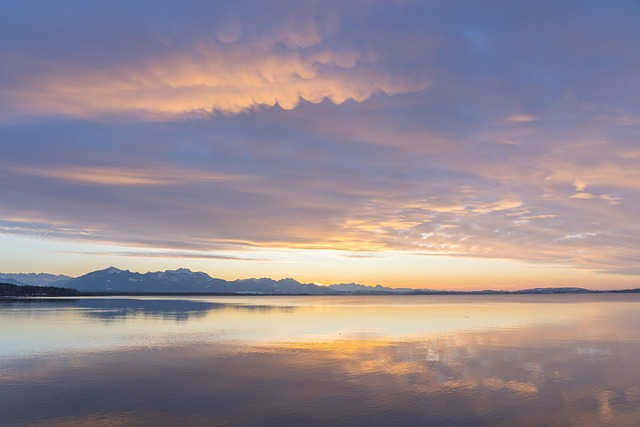

In [83]:
#loading image one
img_one = Image.open("/content/images/image_one.jpg")
image_one_arr = np.array(img_one)
image_one_arr

In [101]:
#loading image two
img_two = Image.open("/content/images/image_two.jpg")
image_two_arr= np.array(img_two)
image_two_arr

array([[[ 30,  24,  10],
        [ 29,  23,   9],
        [ 32,  24,  11],
        ...,
        [147, 168, 151],
        [102, 125, 109],
        [ 75,  99,  85]],

       [[ 25,  19,   5],
        [ 25,  19,   5],
        [ 29,  21,   8],
        ...,
        [118, 139, 120],
        [ 79, 102,  84],
        [ 60,  84,  68]],

       [[ 22,  16,   2],
        [ 23,  17,   3],
        [ 27,  19,   6],
        ...,
        [ 92, 111,  89],
        [ 67,  89,  68],
        [ 63,  87,  65]],

       ...,

       [[ 37,  47,   0],
        [ 36,  46,   0],
        [ 35,  44,   0],
        ...,
        [131, 125,  47],
        [131, 125,  47],
        [129, 123,  45]],

       [[ 39,  49,   0],
        [ 38,  48,   0],
        [ 38,  47,   0],
        ...,
        [133, 127,  49],
        [133, 127,  49],
        [131, 125,  47]],

       [[ 42,  52,   2],
        [ 41,  51,   1],
        [ 40,  49,   2],
        ...,
        [134, 128,  50],
        [134, 128,  50],
        [133, 127,  49]]

In [102]:
#loading image three
img_three = Image.open("/content/images/image_three.jpg")
image_three_arr = np.array(img_three)
image_three_arr

array([[[97, 52, 23],
        [91, 46, 17],
        [88, 43, 14],
        ...,
        [10, 11,  0],
        [11, 11,  0],
        [14, 14,  2]],

       [[91, 46, 17],
        [90, 45, 16],
        [88, 43, 14],
        ...,
        [11, 12,  0],
        [11, 11,  0],
        [12, 12,  0]],

       [[86, 41, 12],
        [90, 45, 16],
        [90, 44, 18],
        ...,
        [13, 14,  0],
        [11, 12,  0],
        [11, 12,  0]],

       ...,

       [[95, 63, 38],
        [91, 59, 34],
        [94, 62, 37],
        ...,
        [73, 99,  2],
        [72, 97,  3],
        [70, 95,  1]],

       [[95, 63, 38],
        [91, 59, 34],
        [94, 62, 37],
        ...,
        [73, 99,  2],
        [72, 97,  3],
        [69, 94,  0]],

       [[94, 62, 37],
        [91, 59, 34],
        [93, 61, 36],
        ...,
        [72, 98,  1],
        [71, 96,  2],
        [69, 94,  0]]], dtype=uint8)

In [86]:
images_arr = [image_one_arr,image_two_arr,image_three_arr]

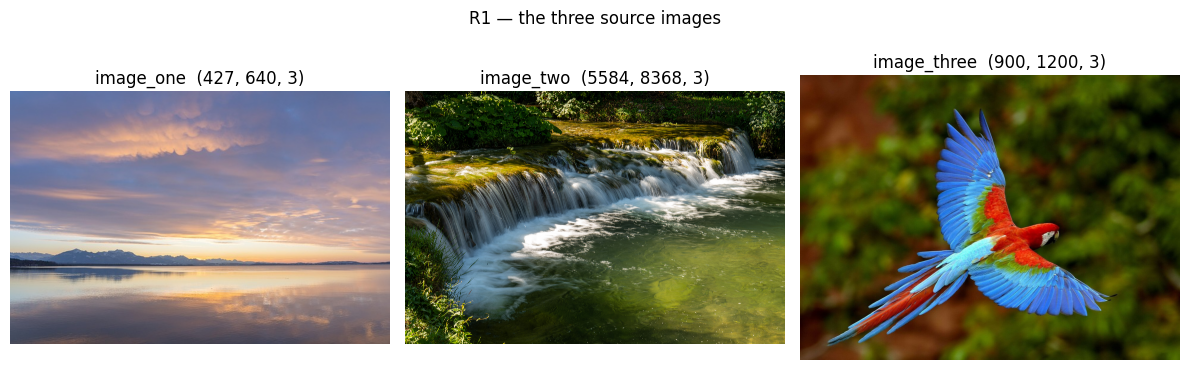

In [87]:
#Show all the 3 images with shape
image_labels = ["image_one", "image_two", "image_three"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, img) in zip(axes, zip(image_labels, images_arr)):
    ax.imshow(img, vmin=0, vmax=1)
    ax.set_title(f"{name}  {img.shape}")
    ax.axis("off")
fig.suptitle("R1 — the three source images")
plt.tight_layout()
plt.show()

# As it is clearly shown above images are 3 dimensional.

*  image_one has (427,640,3) shape and uint8 datatype
*  image_two has (5584, 8368,3) shape and uint8 datatype
*  image_three has (900,1200,3) shape and uint8 datatype








In [99]:
# converting array to gray and converting to float as it's uint8 in [0,255]

img_one_gray_arr = np.array(img_one.convert("L")).astype(np.float64)/255.0
img_two_gray_arr = np.array(img_two.convert("L")).astype(np.float64)/255.0
img_three_gray_arr = np.array(img_three.convert("L")).astype(np.float64)/255.0

images_grey_arr = [img_one_gray_arr,img_two_gray_arr,img_three_gray_arr]

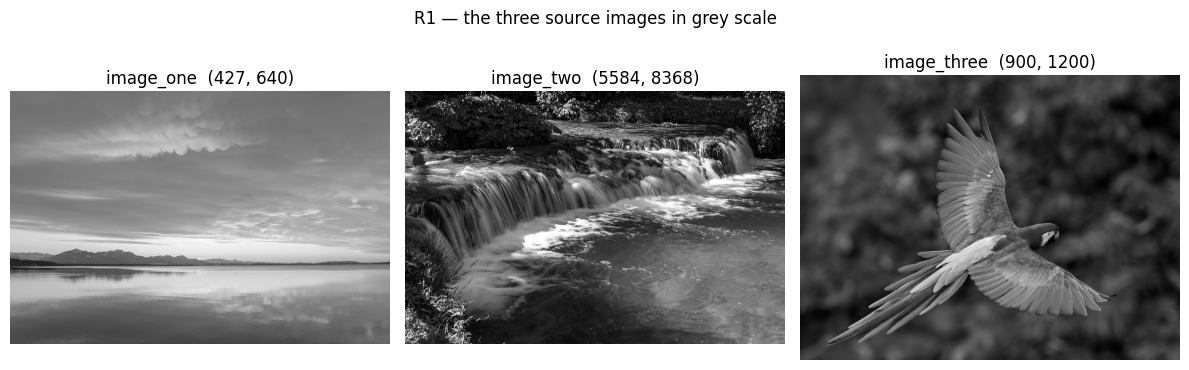

In [100]:
# Show all the 3 images with shape

image_labels = ["image_one", "image_two", "image_three"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, img) in zip(axes, zip(image_labels, images_grey_arr)):
    ax.imshow(img, cmap="gray",vmin=0, vmax=1)
    ax.set_title(f"{name}  {img.shape}")
    ax.axis("off")
fig.suptitle("R1 — the three source images in grey scale")
plt.tight_layout()
plt.show()

# Converted to Greyscale

All images are unsigned int8 [0-255]. So to convert then into greyscale, first it should be convereted to datatype float64.

After converting to grey scale, the images changed to 2 dimension.

Shape of images are:
- image_one = (427,640)
- image_two = (5584, 8368)
- image_three = (900, 1200)